# Netflix Recommendation System — Task 3: SVD (Matrix Factorization)

This notebook runs hyperparameter tuning for the SVD model using Surprise GridSearchCV, trains the model on the full training set, computes RMSE and MAE, plots the learning curve across epochs, and performs latent factor analysis on movies.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from surprise import Dataset, Reader, SVD

sys.path.append(os.path.abspath('..'))
from src import config
from src.models import svd_model
from src.evaluation import compute_rmse, compute_mae

## 1. Load Train and Test Sets

In [2]:
train_df = pd.read_parquet(os.path.join(config.DATA_DIR, 'train_ratings.parquet'))
test_df = pd.read_parquet(os.path.join(config.DATA_DIR, 'test_ratings.parquet'))
print(f'Train size: {len(train_df):,}. Test size: {len(test_df):,}.')

Train size: 4,282,211. Test size: 1,070,569.


## 2. GridSearchCV for SVD Tuning

We tune parameters such as `n_factors` and `lr_all` to find the best fit.

In [3]:
# Using a smaller parameter grid for quick execution
param_grid = {
    'n_factors': [50, 100],
    'n_epochs': [15, 20],
    'lr_all': [0.005],
    'reg_all': [0.02, 0.05]
}
best_params, best_score = svd_model.run_svd_grid_search(train_df, param_grid)

Running SVD Grid Search CV...


Grid Search complete. Best RMSE: 0.9502
Best params: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.05}


[Parallel(n_jobs=1)]: Done  24 out of  24 | elapsed:   15.1s finished


## 3. Train Best Model and Predict

We fit SVD on the full train set and evaluate on test.

In [4]:
model = svd_model.train_svd(train_df, best_params)
svd_model.save_svd_model(model, config.SVD_MODEL_PATH)

# Predict on test set using fast surprise test()
test_testset = list(zip(test_df['user_id'], test_df['movie_id'], test_df['rating']))
predictions = model.test(test_testset)
test_df['pred_rating'] = [p.est for p in predictions]
rmse = compute_rmse(test_df['pred_rating'].values, test_df['rating'].values)
mae = compute_mae(test_df['pred_rating'].values, test_df['rating'].values)
print(f'SVD Test RMSE: {rmse:.4f}')
print(f'SVD Test MAE: {mae:.4f}')

Training SVD model with parameters: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.05}...


SVD model training complete.
Saving SVD model to C:\Users\vivek parihar\.gemini\antigravity\scratch\netflix-recommendation-system\results\svd_model.pkl...


SVD model saved successfully.


SVD Test RMSE: 0.8094
SVD Test MAE: 0.6330


## 4. Plot SVD Learning Curves

We compute RMSE on train and test datasets across varying epochs to evaluate over/underfitting.

Epoch 1: Train RMSE = 0.9044, Test RMSE = 0.9081


Epoch 5: Train RMSE = 0.8456, Test RMSE = 0.8519


Epoch 10: Train RMSE = 0.8135, Test RMSE = 0.8225


Epoch 15: Train RMSE = 0.8026, Test RMSE = 0.8135


Epoch 20: Train RMSE = 0.7974, Test RMSE = 0.8094


Epoch 25: Train RMSE = 0.7941, Test RMSE = 0.8070


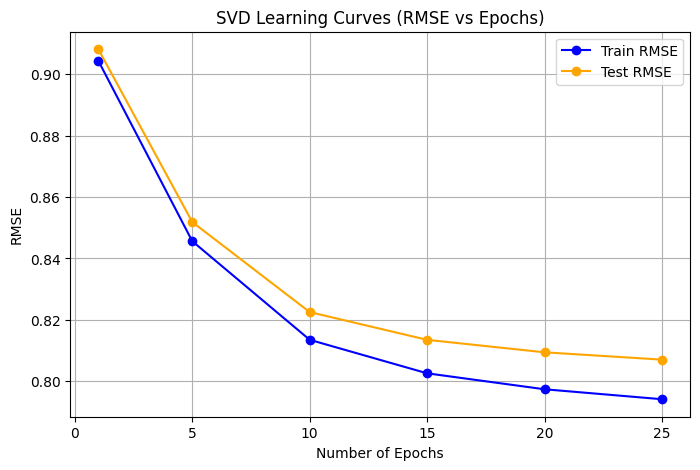

In [5]:
reader = Reader(rating_scale=(1.0, 5.0))
data = Dataset.load_from_df(train_df[['user_id', 'movie_id', 'rating']], reader)
trainset = data.build_full_trainset()

epochs = [1, 5, 10, 15, 20, 25]
train_rmses = []
test_rmses = []

# Sample a representative subset of train set for fast curve calculation without memory issues
train_sample = train_df.sample(min(100000, len(train_df)), random_state=config.RANDOM_STATE)
train_eval_set = list(zip(train_sample['user_id'], train_sample['movie_id'], train_sample['rating']))
test_testset = list(zip(test_df['user_id'], test_df['movie_id'], test_df['rating']))

for ep in epochs:
    model_ep = SVD(n_factors=best_params['n_factors'], n_epochs=ep, 
                   lr_all=best_params['lr_all'], reg_all=best_params['reg_all'], 
                   random_state=config.RANDOM_STATE)
    model_ep.fit(trainset)
    
    # Fast train predictions
    train_preds = model_ep.test(train_eval_set)
    train_rmse = compute_rmse(np.array([p.est for p in train_preds]), train_sample['rating'].values)
    train_rmses.append(train_rmse)
    
    # Fast test predictions
    test_preds_ep = model_ep.test(test_testset)
    test_rmse = compute_rmse(np.array([p.est for p in test_preds_ep]), test_df['rating'].values)
    test_rmses.append(test_rmse)
    print(f'Epoch {ep}: Train RMSE = {train_rmse:.4f}, Test RMSE = {test_rmse:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_rmses, 'o-', color='blue', label='Train RMSE')
plt.plot(epochs, test_rmses, 'o-', color='orange', label='Test RMSE')
plt.title('SVD Learning Curves (RMSE vs Epochs)')
plt.xlabel('Number of Epochs')
plt.ylabel('RMSE')
plt.grid(True)
plt.legend()
plot_path = os.path.join(config.REPORT_FIGS_DIR, '09_svd_learning_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

## 5. Analyze Latent Factors

SVD decomposes the user-item rating matrix. The item matrix `qi` captures movie features. We analyze the principal latent factors to see what movie attributes they represent.

In [6]:
qi = model.qi
movie_raw_ids = [trainset.to_raw_iid(i) for i in range(trainset.n_items)]
movies_df = pd.read_parquet(config.PROCESSED_MOVIES_PARQUET)
movie_id_to_title = dict(zip(movies_df['movie_id'], movies_df['movie_title']))

# Analyze first 3 factors
for factor in range(3):
    factor_values = qi[:, factor]
    sorted_item_indices = np.argsort(factor_values)
    
    print(f'\n--- Latent Factor {factor + 1} ---')
    print('Top 5 Movies (highest value):')
    for idx in sorted_item_indices[-5:][::-1]:
        mid = movie_raw_ids[idx]
        title = movie_id_to_title.get(mid, f'Movie {mid}')
        print(f'  - {title} (Score: {factor_values[idx]:.4f})')
        
    print('Bottom 5 Movies (lowest value):')
    for idx in sorted_item_indices[:5]:
        mid = movie_raw_ids[idx]
        title = movie_id_to_title.get(mid, f'Movie {mid}')
        print(f'  - {title} (Score: {factor_values[idx]:.4f})')


--- Latent Factor 1 ---
Top 5 Movies (highest value):
  - Steel Magnolias (Score: 0.5231)
  - Fried Green Tomatoes (Score: 0.4711)
  - Chicago (Score: 0.4592)
  - Beaches (Score: 0.4333)
  - Moulin Rouge (Score: 0.4184)
Bottom 5 Movies (lowest value):
  - Above the Law (Score: -0.4289)
  - Rambo: First Blood Part II (Score: -0.3930)
  - Fire Down Below (Score: -0.3911)
  - Naked Gun 2 1/2: The Smell of Fear (Score: -0.3900)
  - Hard to Kill (Score: -0.3839)

--- Latent Factor 2 ---
Top 5 Movies (highest value):
  - Armageddon (Score: 0.3898)
  - Pearl Harbor (Score: 0.3521)
  - Gone in 60 Seconds (Score: 0.3264)
  - Swordfish (Score: 0.3186)
  - Independence Day (Score: 0.3157)
Bottom 5 Movies (lowest value):
  - Yojimbo (Score: -0.5117)
  - Metropolis (Score: -0.4477)
  - Crumb (Score: -0.4345)
  - Rashomon (Score: -0.4281)
  - Dr. Strangelove (Score: -0.4256)

--- Latent Factor 3 ---
Top 5 Movies (highest value):
  - The Best of Friends: Season 3 (Score: 0.5175)
  - The Best of Frie